<a href="https://colab.research.google.com/github/pommerlauren-wq/goalkeeper-positioning-analysis/blob/Hannes/notebooks/Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Preprocessing
- Steps taken to clean or transform the data


In [1]:
!pip install mplsoccer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 335.8 kB/s eta 0:00:00


In [2]:
#Import necessary libraries
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import VerticalPitch
from mplsoccer import Sbopen
from tqdm import tqdm
import gdown

#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

#Initialize parser
parser = Sbopen()

In [3]:
matches_df = parser.match(competition_id=72, season_id=107)
match_ids = matches_df['match_id'].tolist()

all_shots = []

for match_id in match_ids:
    df_event, df_related, df_freeze, df_tactics = parser.event(match_id)

    df_shots = df_event[df_event['type_name'] == 'Shot'].copy()

    df_shots['match_id'] = match_id

    all_shots.append(df_shots)

shots_master_women_world_cup_df = pd.concat(all_shots, ignore_index=True)

In [4]:
#Lets look at the example dataset from the Women's World Cup 2023 again. It consisted of 1680 shots. 184 of them were goals.
num_goals = shots_master_women_world_cup_df[shots_master_women_world_cup_df['outcome_name'] == 'Goal'].shape[0]
print(f"Number of goals: {num_goals}")


Number of goals: 184


In [ ]:
#As many more competitions are available the next step is to create a shots_master_df for all shots from all competitions to enrich the dataset on which to train the models later.

#During data loading and exploration these columns were discovered to always be NaN for type_name = Shot. Therefore, they are not of interest for the shots_master_df
irrelevant_columns = [
    'tactics_formation', 'pass_recipient_id', 'pass_recipient_name', 'pass_length',
    'pass_angle', 'pass_height_id', 'pass_height_name', 'counterpress', 'pass_switch',
    'block_deflection', 'pass_cross', 'pass_assisted_shot_id', 'pass_shot_assist',
    'goalkeeper_position_id', 'goalkeeper_position_name', 'foul_committed_card_id',
    'foul_committed_card_name', 'ball_recovery_recovery_failure', 'foul_committed_advantage',
    'foul_won_advantage', 'foul_won_defensive', 'dribble_nutmeg', 'pass_goal_assist',
    'substitution_replacement_id', 'substitution_replacement_name', 'bad_behaviour_card_id',
    'bad_behaviour_card_name', 'pass_cut_back', 'dribble_overrun', 'ball_recovery_offensive',
    'pass_no_touch', 'pass_deflected', 'foul_committed_penalty', 'foul_won_penalty',
    'injury_stoppage_in_chain', 'foul_committed_offensive', 'block_offensive',
    'pass_miscommunication', 'block_save_block', 'dribble_no_touch', 'player_off_permanent'
]

all_shots = []

df_competitions = parser.competition()

# Add mininterval or miniters to slow down tqdm output
for _, row in tqdm(df_competitions.iterrows(), total=len(df_competitions), desc="Competitions", mininterval=2.0):
    comp_id = row['competition_id']
    season_id = row['season_id']
    comp_name = row['competition_name']
    season_name = row['season_name']

    tqdm.write(f"\n🔄 Processing {comp_name} - {season_name}...")

    try:
        matches_df = parser.match(competition_id=comp_id, season_id=season_id)
        match_ids = matches_df['match_id'].tolist()

        for match_id in tqdm(
            match_ids,
            desc=f"  Matches in {comp_name[:15]} {season_name}",
            leave=False,
            mininterval=20,
        ):
            try:
                df_event, df_related, df_freeze, df_tactics = parser.event(match_id)
                df_shots = df_event[df_event['type_name'] == 'Shot'].copy()
                df_shots['match_id'] = match_id
                all_shots.append(df_shots)
            except Exception as e:
                print(f"     ❌ Error in match_id {match_id}: {e}")

    except Exception as e:
        print(f"❌ Could not fetch matches for {comp_name} - {season_name}: {e}")

shots_master_df = pd.concat(all_shots, ignore_index=True)
shots_master_df = shots_master_df.drop(columns=[col for col in irrelevant_columns if col in shots_master_df.columns])

print("\n✅ All done!")
print("📊 Final shape of shots_master_df:", shots_master_df.shape)


Competitions:   0%|          | 0/75 [00:00<?, ?it/s]


🔄 Processing 1. Bundesliga - 2023/2024...



Competitions:   1%|▏         | 1/75 [00:40<49:41, 40.29s/it]


🔄 Processing 1. Bundesliga - 2015/2016...



  Matches in 1. Bundesliga 2015/2016:  77%|███████▋  | 236/306 [04:07<01:12,  1.04s/it]

In [ ]:
#Since creating the dataset took more than 40 minutes I want to permanently safe it to a .csv, that I can always access. Before saving I reorder the columns.

ordered_columns = [
    #identifiers
    'id',
    'index',
    'match_id',

    #time information
    'period',
    'timestamp',

    #team and player columns
    'team_id',
    'team_name',
    'player_id',
    'player_name',
    'position_id',
    'position_name',

    #location columns
    'x',
    'y',
    'end_x',
    'end_y',
    'end_z',

    #shot details
    'body_part_id',
    'body_part_name',
    'sub_type_id',
    'sub_type_name',
    'technique_id',
    'technique_name',
    'shot_statsbomb_xg',
    'shot_key_pass_id',
    'under_pressure',
    'off_camera',
    'out',
    'aerial_won',

    #special attributes
    'shot_first_time',
    'shot_one_on_one',
    'shot_deflected',
    'shot_open_goal',
    'shot_redirect',
    'shot_follows_dribble',

    #outcome
    'outcome_id',
    'outcome_name',

    #rare or redundant
    'minute',
    'second',
    'duration',
    'half_start_late_video_start',
    'half_end_early_video_end',
    'pass_backheel',
    'possession',
    'possession_team_id',
    'possession_team_name',
    'play_pattern_id',
    'play_pattern_name'
]

shots_master_df = shots_master_df[[col for col in ordered_columns if col in shots_master_df.columns]]

In [ ]:
shots_master_df.to_csv("shots_master_df.csv", index=False)

In [ ]:
print(shots_master_df.shape)
shots_master_df.head()

In [ ]:
#As the shots_master_df has now been stored to a csv and was uploaded to Google Drive we can access it from there

file_id = '1DNvQtuRq3f-xYvh4McKdJo5j3hMZI2DB'
url = f'https://drive.google.com/uc?id={file_id}'

shots_master_df = pd.read_csv(url)

print(shots_master_df.shape)
shots_master_df.head()

In [ ]:
shots_master_df.info()


In [ ]:
#Shots_master_df has 87111 rows and 9667 rows.
num_goals_master = shots_master_df[shots_master_df['outcome_name'] == 'Goal'].shape[0]
print(f"Number of goals in shots_master_df: {num_goals_master}")

In [ ]:
#The dataframe already has columns, that could be potential features for the models. Others have to be constructed. That will happen next, starting with the distance to Goal.
#For that it is important to understand the statsbomb coordinate system.

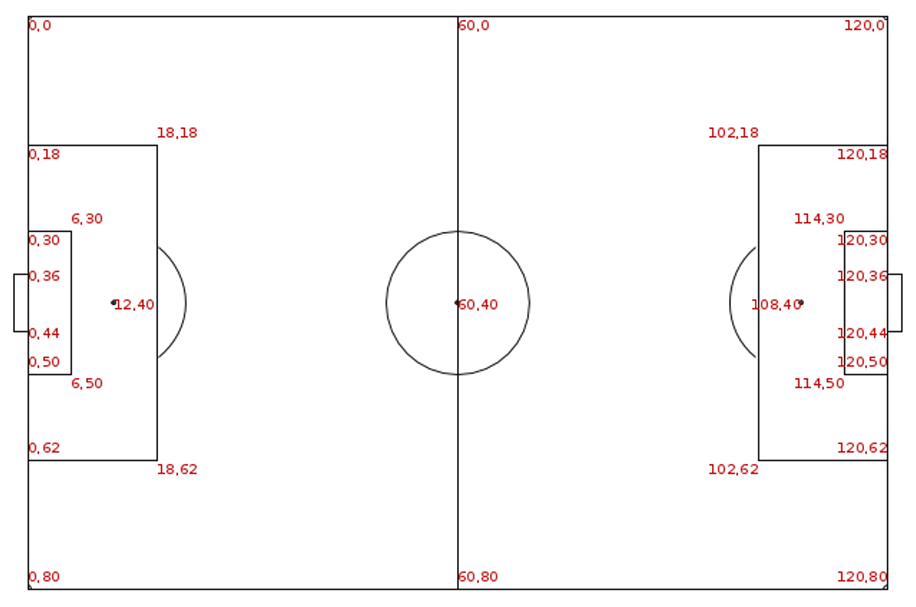

In [ ]:
#All shots are mapped onto one goal in the Statsbomb data, allowing visualization using just half the pitch.

first_300_goals = shots_master_df[shots_master_df['outcome_name'] == 'Goal'].iloc[:300]

pitch = VerticalPitch(pitch_type='statsbomb', line_color='black', half = True)
fig, ax = pitch.draw(figsize=(10, 6))

pitch.scatter(first_300_goals['x'], first_300_goals['y'], ax=ax, color='red', edgecolors='black',alpha = 0.6, s=50, label='Goals')

plt.title('First 300 Goals')
plt.legend(loc = 'upper left')
plt.show()

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(shots_master_df['x'], bins=30, kde=False, ax=axs[0, 0], color='skyblue')
axs[0, 0].set_title('Distribution of x (Start X)')

sns.histplot(shots_master_df['y'], bins=30, kde=False, ax=axs[0, 1], color='lightgreen')
axs[0, 1].set_title('Distribution of y (Start Y)')

sns.histplot(shots_master_df['end_x'], bins=30, kde=False, ax=axs[1, 0], color='salmon')
axs[1, 0].set_title('Distribution of end_x (End X)')

sns.histplot(shots_master_df['end_y'], bins=30, kde=False, ax=axs[1, 1], color='violet')
axs[1, 1].set_title('Distribution of end_y (End Y)')

plt.tight_layout()
plt.show()


In [ ]:
#We can see that the shots are directed towards the goal with the center located at x = 120, y = 40. Strong outliers are considered very bad attempts.
#IMPORTANT: Statbomb uses the coordinates to standardize their measurements across pitches of different sizes. This is useful for modeling and plotting, especially for visual consistency across competitions and leagues.
#Therefore, the distance to goal is not calculated in meters but in pitch units. It can be calculated using Eukledian Distance.

GOAL_CENTER_X = 120
GOAL_CENTER_Y = 40

shots_master_df['distance_to_goal'] = np.sqrt(
    (GOAL_CENTER_X - shots_master_df['x'])**2 +
    (GOAL_CENTER_Y - shots_master_df['y'])**2
)

shots_master_df[['id','period', 'timestamp', 'team_id', 'team_name', 'player_id', 'player_name', 'x', 'y', 'distance_to_goal', 'match_id', 'outcome_name']].head()

In [ ]:
#TO DO: Plot distance to goal scatter plot

In [ ]:
#Now I want to visualy show an example how distance to goal works. Let's look at a random match of Spain's women in the 2023 World Cup
parser = Sbopen()
matches_df = parser.match(competition_id=72, season_id=107)
matches_df = matches_df[(matches_df["home_team_name"] == "Spain Women's")|(matches_df["away_team_name"] == "Spain Women's")]
print(matches_df['match_id'].unique())

dis_to_goal_df = shots_master_df[['id','period', 'timestamp', 'team_id', 'team_name', 'player_id', 'player_name', 'x', 'y', 'distance_to_goal', 'match_id', 'outcome_name']]

goals_df = dis_to_goal_df[
    (dis_to_goal_df['match_id'] == 3902240) &
    (dis_to_goal_df['outcome_name'] == 'Goal')
]

goals_df.head()

In [ ]:
GOAL_CENTER_X = 120
GOAL_CENTER_Y = 40


pitch = VerticalPitch(pitch_type='statsbomb', line_color='black', half = True)
fig, ax = pitch.draw(
    #figsize=(6, 10)
)

pitch.scatter(GOAL_CENTER_X, GOAL_CENTER_Y, s=20, c='red', ax=ax, label='Goal Center')

for _, row in goals_df.iterrows():
    shot_x = row['x']
    shot_y = row['y']
    distance = row['distance_to_goal']

    pitch.scatter(shot_x, shot_y, ax=ax, c='gold', s=50)

    pitch.lines(shot_x, shot_y, GOAL_CENTER_X, GOAL_CENTER_Y, ax=ax, color='green', lw=1.5)

    mid_x = (shot_x + GOAL_CENTER_X) / 2
    mid_y = (shot_y + GOAL_CENTER_Y) / 2
    pitch.annotate(
      f"{distance:.1f}pu",
      xy=(mid_x, mid_y),
      ax=ax,
      fontsize=7,
      ha='center',
      color='black',
      bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round', pad=0.1)
    )

ax.set_title('Distance to Goal', fontsize=16)
ax.legend()
plt.show()

#One goal was a penalty. Because the coordinate system penalty spot is at 108,40 and the center of the goal is at 120,40 distance_to_goal is 12.

In [ ]:
#The next feature to consider is the angle to the goal. For that the goalposts need to be considered.

#Goalposts y-coordinates
goal_y1 = 36  #left post
goal_y2 = 44  #right post
GOAL_WIDTH = 8

#Shot coordinates
x = shots_master_df['x'].to_numpy()
y = shots_master_df['y'].to_numpy()

#Distances from shot to left and right goalposts
a = np.sqrt((GOAL_CENTER_X - x)**2 + (goal_y1 - y)**2)
b = np.sqrt((GOAL_CENTER_X - x)**2 + (goal_y2 - y)**2)
c = GOAL_WIDTH

denominator = 2 * a * b
cos_angle = (a**2 + b**2 - c**2) / denominator
cos_angle = np.clip(cos_angle, -1.0, 1.0)

angle_radians = np.arccos(cos_angle)

shots_master_df['angle_to_goal'] = angle_radians
shots_master_df['angle_to_goal_deg'] = np.degrees(angle_radians)

In [ ]:
angle_to_goal_df = shots_master_df[['id' ,'period', 'timestamp', 'team_id', 'team_name', 'player_id', 'player_name', 'x', 'y', 'angle_to_goal','angle_to_goal_deg', 'match_id', 'outcome_name']]

goal_angles_df = angle_to_goal_df[
    (angle_to_goal_df['match_id'] == 3902240) &
    (angle_to_goal_df['outcome_name'] == 'Goal')
]

goal_angles_df.head()

In [ ]:
goal_x, goal_y = 120, 40
left_post_y = 36
right_post_y = 44
goal_width = 8

pitch = VerticalPitch(pitch_type='statsbomb', line_color='black', half=True)
fig, ax = pitch.draw()

for i, row in goal_angles_df.iterrows():
    shot_x = row['x']
    shot_y = row['y']
    angle = row['angle_to_goal_deg']

    pitch.scatter(shot_x, shot_y, ax=ax, c='gold', s=50, label='Goal' if i == 0 else None)

    pitch.lines(shot_x, shot_y, goal_x, left_post_y, ax=ax, color='blue', lw=1.5, linestyle='--')
    pitch.lines(shot_x, shot_y, goal_x, right_post_y, ax=ax, color='blue', lw=1.5, linestyle='--')

    pitch.annotate(
        f"{angle:.2f} °",
        xy=(shot_x, shot_y),
        ax=ax,
        fontsize=8,
        ha='left',
        color='blue',
        xytext=(5, 5),
        textcoords='offset points',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round' ,pad=0.2)
    )

ax.set_title('Shot Angles for Goals', fontsize=16)
ax.legend()
plt.show()

#For the penalty, if placed perfectly at 108, 40 the angle would be ~36.9°.
#However, this specific penalty is placed at 108.1, 40.1 which equals an angle of 37.2°

In [ ]:
#Another feature that is intuetively relevent would be how many players are between the goal and the shoot position.
#My first idea is to reuse the triangle used to calculated the angle for this and identify all players within the triangle as "in the way".
#I want to distinct between teammates and opponents as the teammates will try to avoid blocking the shoot and the opponents obviously wont.

df_event, df_related, df_freeze, df_tactics = parser.event(3902240)
first_goal_freeze_df = df_freeze[df_freeze["id"] == '723925a1-dbde-4898-a8be-bbabe9588e56']
first_goal_freeze_df.head(3)

In [ ]:
all_freeze_frames = []

shots_grouped = shots_master_df.groupby('match_id')

for match_id, shots_in_match in tqdm(shots_grouped, total=len(shots_grouped), desc="Getting freeze frames"):

    try:
        _, _, df_freeze, _ = parser.event(match_id)

        if df_freeze is None or df_freeze.empty:
            continue

        shot_ids = shots_in_match['id'].unique()
        df_filtered_freeze = df_freeze[df_freeze['id'].isin(shot_ids)].copy()

        if df_filtered_freeze.empty:
            continue

        df_filtered_freeze['match_id'] = match_id

        all_freeze_frames.append(df_filtered_freeze)

    except Exception as e:
        print(f"❌ Error fetching freeze frames for match {match_id}: {e}")

if all_freeze_frames:
    freeze_master_df = pd.concat(all_freeze_frames, ignore_index=True)
    print("✅ Freeze frame data collected:", freeze_master_df.shape)
else:
    print("⚠️ No freeze frame data was collected.")


In [ ]:
freeze_master_df.to_csv("freeze_master_df.csv", index=False)

In [ ]:
file_id = '1ut7kYQAxmXQfavlHvYD_EGoWu8rMWlcQ'
url = f'https://drive.google.com/uc?id={file_id}'

output = 'freeze_master_df.csv'

gdown.download(url, output, quiet=False)

freeze_master_df = pd.read_csv(output)

print(freeze_master_df.shape)
freeze_master_df.head(5)

In [ ]:
freeze_master_df.info()

In [ ]:
left_post = np.array([120, 36])
right_post = np.array([120, 44])

def point_in_triangle(pt, v1, v2, v3):
    def sign(p1, p2, p3):
        return (p1[0] - p3[0]) * (p2[1] - p3[1]) - (p2[0] - p3[0]) * (p1[1] - p3[1])

    b1 = sign(pt, v1, v2) < 0.0
    b2 = sign(pt, v2, v3) < 0.0
    b3 = sign(pt, v3, v1) < 0.0

    return ((b1 == b2) and (b2 == b3))

In [ ]:
from tqdm import tqdm

freeze_grouped = freeze_master_df.groupby(['match_id', 'id'])

shots_master_df['opponents_in_way'] = 0
shots_master_df['teammates_in_way'] = 0

for idx, shot in tqdm(shots_master_df.iterrows(), total=len(shots_master_df), desc="Counting players in triangle"):
    match_id = shot['match_id']
    event_id = shot['id']
    shooter_team_id = shot['team_id']
    shot_x = shot['x']
    shot_y = shot['y']

    try:
        freeze = freeze_grouped.get_group((match_id, event_id))
    except KeyError:
        continue

    v1 = np.array([shot_x, shot_y])
    v2 = left_post
    v3 = right_post

    opponents = 0
    teammates = 0

    for _, row in freeze.iterrows():
        #if row['position_name'] == 'Goalkeeper':
        #    continue

        player_x = row['x']
        player_y = row['y']
        player_team_id = row['teammate']

        pt = np.array([player_x, player_y])
        if point_in_triangle(pt, v1, v2, v3):
            if player_team_id:
                teammates += 1
            else:
                opponents += 1

    shots_master_df.at[idx, 'opponents_in_way'] = opponents
    shots_master_df.at[idx, 'teammates_in_way'] = teammates


In [ ]:
left_post = np.array([120, 36])
right_post = np.array([120, 44])

goal_ids = [
    '7c9b6e01-2124-4135-9fb7-81350a3b474e',
    '723925a1-dbde-4898-a8be-bbabe9588e56',
    '4e9448ed-25c8-4538-a023-8829ec229c42'
]

match_id = 3902240

goal_shots = shots_master_df[
    (shots_master_df['match_id'] == match_id) & (shots_master_df['id'].isin(goal_ids))
]

for i, (_, shot) in enumerate(goal_shots.iterrows(), 1):
    shot_id = shot['id']
    shot_loc = np.array([shot['x'], shot['y']])

    freeze = freeze_master_df[
        (freeze_master_df['match_id'] == match_id) & (freeze_master_df['id'] == shot_id)
    ]

    teammates = freeze[freeze['teammate'] == True]
    opponents = freeze[freeze['teammate'] == False]
    goalkeeper = opponents[opponents['position_name'] == 'Goalkeeper']
    other_opponents = opponents[opponents['position_name'] != 'Goalkeeper']

    pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='white', line_color='black', half = True)
    fig, ax = pitch.draw(
        figsize=(10, 6)
    )

    triangle = np.array([shot_loc, left_post, right_post])
    pitch.polygon([triangle], ax=ax, color='orange', alpha=0.3, edgecolor='black', label='Shot Triangle')

    pitch.scatter(teammates['x'], teammates['y'], ax=ax, color='red', label='Teammates', alpha=0.6, s=50)
    pitch.scatter(other_opponents['x'], other_opponents['y'], ax=ax, color='blue', label='Opponents', alpha=0.6, s=50)
    pitch.scatter(goalkeeper['x'], goalkeeper['y'], ax=ax, color='green', label='Goalkeeper', alpha=0.6, s=50)

    pitch.scatter([shot_loc[0]], [shot_loc[1]], ax=ax, color='red',edgecolor = 'black', s=50, label='Shot Location')

    ax.set_title(f"Goal Shot Triangle and Freeze Frame (Goal {i})", fontsize=16)
    ax.legend(loc='upper left')
    plt.show()


In [ ]:
#Looking at the plots from above it might be that for penalties there is no freeze_frame and therefore no goalkeeper can be seen.


# Set opponents_in_way to 1 where sub_type_name is 'Penalty'
shots_master_df.loc[shots_master_df['sub_type_name'] == 'Penalty', 'opponents_in_way'] = 1

shots_master_df.groupby('sub_type_name')[['opponents_in_way', 'teammates_in_way']].mean().sort_values(by='opponents_in_way', ascending=False)


#As we will filter apply the models only to open play goals and therefore filter dataset anyways, this is not big of a deal.

In [ ]:
#In case the distinction between opponents and teammates does not matter I also create a players_in_way column which sums both opponents and teammates per shot.
shots_master_df['players_in_way'] = shots_master_df['opponents_in_way'] + shots_master_df['teammates_in_way']

In [ ]:
#The next feature of interest could be if the shot is performed with the dominant or the non-dominant foot.
num_players = shots_master_df['player_id'].nunique()
print(f"Number of unique players: {num_players}")



In [ ]:
file_id_dominant = '1y14w6jD-X2B2opaX6uCCgup0gsQW_EJz'
url = f'https://drive.google.com/uc?id={file_id_dominant}'

dominant_foot_df = pd.read_csv(url)

print(dominant_foot_df.shape)
dominant_foot_df.head(15)


In [ ]:
dominant_foot_subset = dominant_foot_df[['player_id', 'dominant_foot']]

shots_master_df = shots_master_df.merge(
    dominant_foot_subset,
    on='player_id',
    how='left'
)

print(shots_master_df.shape)
shots_master_df.head()

In [ ]:
print(shots_master_df['dominant_foot'].value_counts(dropna=False))

In [ ]:
print(shots_master_df['body_part_name'].value_counts(dropna=False))

In [ ]:
shots_master_df = shots_master_df[
    shots_master_df['dominant_foot'].notna() |
    (shots_master_df['body_part_name'].isin(['Head', 'Other']))
]
print(shots_master_df.shape)

In [ ]:
print(shots_master_df['dominant_foot'].value_counts(dropna=False))

In [ ]:
print(shots_master_df['body_part_name'].value_counts(dropna=False))

In [ ]:
import numpy as np

def is_with_dominant(row):
    body = row['body_part_name']
    dom = row['dominant_foot']
    if body == 'Right Foot':
        return dom in ['right', 'both']
    elif body == 'Left Foot':
        return dom in ['left', 'both']
    elif body in ['Head', 'Other']:
        return np.nan
    else:
        return np.nan

shots_master_df['with_dominant_foot'] = shots_master_df.apply(is_with_dominant, axis=1)

print(shots_master_df['with_dominant_foot'].value_counts(dropna=False))


In [ ]:
#The next feature is a boolean under pressure. It already exists in the data. The only thing left to do is filling the NaN values with 0
shots_master_df['under_pressure'] = shots_master_df['under_pressure'].fillna(0)
shots_master_df['under_pressure'] = shots_master_df['under_pressure'].astype(int)
shots_master_df['under_pressure'].value_counts(dropna=False)

selected_cols = ['shot_first_time', 'shot_one_on_one', 'shot_open_goal']

for col in selected_cols:
    shots_master_df[col] = shots_master_df[col].notna().astype(int)

In [ ]:
#Another feature could be the shot technique. For that I want to use one hot encodings.
technique_dummies = pd.get_dummies(shots_master_df['technique_name'], prefix='technique')
shots_master_df = pd.concat([shots_master_df, technique_dummies], axis=1)

In [ ]:
#The same idea appiles for types of play. Open Play shots might have lower scoring probability than penalties
subtype_dummies = pd.get_dummies(shots_master_df['sub_type_name'], prefix='subtype')
shots_master_df = pd.concat([shots_master_df, subtype_dummies], axis=1)

In [ ]:
# Mark headers explicitly
shots_master_df['is_header'] = (shots_master_df['body_part_name'] == 'Head').astype(int)

# Encode dominant foot: set neutral value (e.g., 0.5) for headers
shots_master_df['with_dominant_foot'] = np.where(
    shots_master_df['is_header'] == 1, 0.5,
    shots_master_df['with_dominant_foot'].map({True: 1, False: 0})
)

In [ ]:
shots_master_df['goal'] = shots_master_df.apply(lambda row:1 if row['outcome_name']=='Goal' else 0, axis=1)

In [ ]:
shots_master_df.info()

In [ ]:
print(shots_master_df['body_part_name'].value_counts(dropna=False))


In [ ]:
shots_master_df = shots_master_df[shots_master_df['body_part_name'].isin(['Right Foot', 'Left Foot', 'Head'])]

In [ ]:
print(shots_master_df['body_part_name'].value_counts(dropna=False))

In [ ]:
print(shots_master_df['technique_name'].value_counts(dropna=False))


In [ ]:
# Group by technique_name and calculate goal rate
goal_rates_by_technique = (
    shots_master_df
    .groupby('technique_name')['goal']
    .agg(['count', 'sum'])
    .assign(goal_rate=lambda df: df['sum'] / df['count'])
    .sort_values('goal_rate', ascending=False)
)

print(goal_rates_by_technique)

In [ ]:
goal_rates_by_subtype = (
    shots_master_df
    .groupby('sub_type_name')['goal']
    .agg(['count', 'sum'])
    .assign(goal_rate=lambda df: df['sum'] / df['count'])
    .sort_values('goal_rate', ascending=False)
)

print(goal_rates_by_subtype)


In [ ]:
#Find rows where either Corner or Kick Off is active
rows_to_drop = (shots_master_df['subtype_Corner']) | (shots_master_df['subtype_Kick Off'])

#Drop those rows
shots_master_df = shots_master_df[~rows_to_drop]


In [ ]:
shots_master_df.drop(['subtype_Corner', 'subtype_Kick Off'], axis=1, inplace=True)

In [ ]:
shots_master_df.info()

In [ ]:
shots_master_df.to_csv("finished_preprocessing.csv", index=False)